In [1]:
import geopandas as gpd
import numpy as np
import os, json, pickle, ast
from pathlib import Path

# ── CONFIG ──────────────────────────────────────────────────────────────────
GEOJSON_FOLDER = "/home/group4/project/TreeSatAIPatchsize5_5" #( 5x5)
OUTPUT_FOLDER  = "/home/group4/Transformers_Nathalia/project/Output_data/train_spectral"
LABEL_LEVEL    = "l3_species"   # 19 classes — change to "l2_genus" or "l1_leaf_types" if needed
# ────────────────────────────────────────────────────────────────────────────

BANDS = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']  # C = 10
N_DATES  = 8
N_PIXELS = 25   # 5x5 patch, flattened

# Actual acquisition dates from your GEE script
DATES = {
    "0": "20220301",
    "1": "20220401",
    "2": "20220501",
    "3": "20220601",
    "4": "20220701",
    "5": "20220801",
    "6": "20220901",
    "7": "20221001",
}

def get_col(band, t):
    return band if t == 0 else f"{band}_{t}"

def parse_cell(val):
    """Parse nested list cell → flat float32 array of length N_PIXELS."""
    if val is None:
        return None
    if isinstance(val, str):
        try:
            val = ast.literal_eval(val)
        except:
            return None
    arr = np.array(val, dtype=np.float32).flatten()  # (5,5) → (25,)
    if len(arr) != N_PIXELS:
        return None  # unexpected shape, skip
    return arr

def row_to_tcs(row):
    """
    Convert one GDF row → array (T=8, C=15, S=25).
    Also returns a boolean valid mask of shape (T,).
    """
    out   = np.zeros((N_DATES, len(BANDS), N_PIXELS), dtype=np.float32)
    valid = np.ones(N_DATES, dtype=bool)

    for t in range(N_DATES):
        for c, band in enumerate(BANDS):
            arr = parse_cell(row[get_col(band, t)])
            if arr is None:
                valid[t] = False
                out[t, c, :] = 0.0   # fill missing date with zeros
            else:
                out[t, c, :] = arr

    return out, valid

# ── MAIN BUILD ───────────────────────────────────────────────────────────────
def build_dataset(geojson_folder, output_folder, label_level=LABEL_LEVEL):
    out = Path(output_folder)
    (out / "DATA").mkdir(parents=True, exist_ok=True)
    (out / "META").mkdir(parents=True, exist_ok=True)

    files = sorted([f for f in os.listdir(geojson_folder) if f.endswith(".geojson")])

    # ── Build label map from all files ──────────────────────────────────────
    label_set = set()
    for fname in files:
        gdf = gpd.read_file(os.path.join(geojson_folder, fname))
        label_set.update(gdf[label_level].dropna().unique())
    label_map = {name: i for i, name in enumerate(sorted(label_set))}
    print(f"Found {len(label_map)} classes:")
    for name, idx in label_map.items():
        print(f"  [{idx}] {name}")

    # ── Process each file ───────────────────────────────────────────────────
    labels_dict = {}
    all_arrays  = []
    sample_id   = 0
    skipped     = 0

    for fname in files:
        gdf = gpd.read_file(os.path.join(geojson_folder, fname))
        species = fname.replace(".geojson", "")
        print(f"\n▶ {species}  ({len(gdf)} trees)")

        for _, row in gdf.iterrows():
            label = row.get(label_level)
            if label not in label_map:
                skipped += 1
                continue

            arr, valid = row_to_tcs(row)

            # Skip if more than 2 dates are missing (out of 8)
            if valid.sum() < 6:
                skipped += 1
                continue

            uid = f"sample_{sample_id:06d}"
            np.save(out / "DATA" / f"{uid}.npy", arr)
            labels_dict[uid] = label_map[label]
            all_arrays.append(arr)
            sample_id += 1

        print(f"  → {sample_id} samples saved so far")

    print(f"\n✓ Total samples : {sample_id}")
    print(f"  Skipped        : {skipped}")
    print(f"  Array shape    : T={N_DATES}, C={len(BANDS)}, S={N_PIXELS}")

    # ── labels.json ─────────────────────────────────────────────────────────
    with open(out / "META" / "labels.json", "w") as f:
        json.dump({label_level: labels_dict}, f, indent=2)

    # ── class_map.json (human-readable, for your reference) ─────────────────
    with open(out / "META" / "class_map.json", "w") as f:
        json.dump({v: k for k, v in label_map.items()}, f, indent=2)  # idx → name

    # ── dates.json ──────────────────────────────────────────────────────────
    with open(out / "META" / "dates.json", "w") as f:
        json.dump(DATES, f, indent=2)

    # ── normalisation_values.pkl (channel-wise mean/std) ────────────────────
    big   = np.stack(all_arrays, axis=0)          # (N, T, C, S)
    means = big.mean(axis=(0, 1, 3))              # (C,)
    stds  = big.std(axis=(0, 1, 3))               # (C,)
    stds[stds == 0] = 1e-6
    with open(out / "normalisation_values.pkl", "wb") as f:
        pickle.dump((means, stds), f)

    print(f"✓ Normalisation: means={np.round(means,4)}, stds={np.round(stds,4)}")
    print(f"\n✓ Dataset ready at: {output_folder}")
    print(f"  class_map saved to META/class_map.json — keep this for decoding predictions!")

build_dataset(GEOJSON_FOLDER, OUTPUT_FOLDER)

Found 19 classes:
  [0] alder
  [1] birch
  [2] black pine
  [3] cherry
  [4] douglas fir
  [5] english oak
  [6] european ash
  [7] european beech
  [8] european larch
  [9] japanese larch
  [10] linden
  [11] norway spruce
  [12] poplar
  [13] red oak
  [14] scots pine
  [15] sessile oak
  [16] silver fir
  [17] sycamore maple
  [18] weymouth pine

▶ alder  (2143 trees)
  → 2131 samples saved so far

▶ birch  (2468 trees)
  → 4566 samples saved so far

▶ blackpine  (412 trees)
  → 4966 samples saved so far

▶ cherry  (247 trees)
  → 5213 samples saved so far

▶ douglasfir  (2185 trees)
  → 7381 samples saved so far

▶ englishoak  (2808 trees)
  → 10139 samples saved so far

▶ europeanash  (2202 trees)
  → 12330 samples saved so far

▶ europeanbeech  (4756 trees)
  → 17025 samples saved so far

▶ europeanlarch  (1139 trees)
  → 18156 samples saved so far

▶ japaneselarch  (1613 trees)
  → 19754 samples saved so far

▶ linden  (161 trees)
  → 19912 samples saved so far

▶ norwayspruce 

In [2]:
import geopandas as gpd
import numpy as np
import os, json, pickle, ast
from pathlib import Path

# ── CONFIG ──────────────────────────────────────────────────────────────────
GEOJSON_FOLDER = "/home/group4/project/TreeSatAIPatchsize5_5" #( 5x5)
OUTPUT_FOLDER  = "/home/group4/Transformers_Nathalia/project/Output_data/train_vegetation"
LABEL_LEVEL    = "l3_species"   # 19 classes — change to "l2_genus" or "l1_leaf_types" if needed
# ────────────────────────────────────────────────────────────────────────────

BANDS = ['EVI', 'EVI2', 'NDVI', 'NDWI', 'SAVI']  # C = 5
N_DATES  = 8
N_PIXELS = 25   # 5x5 patch, flattened

# Actual acquisition dates from your GEE script
DATES = {
    "0": "20220301",
    "1": "20220401",
    "2": "20220501",
    "3": "20220601",
    "4": "20220701",
    "5": "20220801",
    "6": "20220901",
    "7": "20221001",
}

def get_col(band, t):
    return band if t == 0 else f"{band}_{t}"

def parse_cell(val):
    """Parse nested list cell → flat float32 array of length N_PIXELS."""
    if val is None:
        return None
    if isinstance(val, str):
        try:
            val = ast.literal_eval(val)
        except:
            return None
    arr = np.array(val, dtype=np.float32).flatten()  # (5,5) → (25,)
    if len(arr) != N_PIXELS:
        return None  # unexpected shape, skip
    return arr

def row_to_tcs(row):
    """
    Convert one GDF row → array (T=8, C=15, S=25).
    Also returns a boolean valid mask of shape (T,).
    """
    out   = np.zeros((N_DATES, len(BANDS), N_PIXELS), dtype=np.float32)
    valid = np.ones(N_DATES, dtype=bool)

    for t in range(N_DATES):
        for c, band in enumerate(BANDS):
            arr = parse_cell(row[get_col(band, t)])
            if arr is None:
                valid[t] = False
                out[t, c, :] = 0.0   # fill missing date with zeros
            else:
                out[t, c, :] = arr

    return out, valid

# ── MAIN BUILD ───────────────────────────────────────────────────────────────
def build_dataset(geojson_folder, output_folder, label_level=LABEL_LEVEL):
    out = Path(output_folder)
    (out / "DATA").mkdir(parents=True, exist_ok=True)
    (out / "META").mkdir(parents=True, exist_ok=True)

    files = sorted([f for f in os.listdir(geojson_folder) if f.endswith(".geojson")])

    # ── Build label map from all files ──────────────────────────────────────
    label_set = set()
    for fname in files:
        gdf = gpd.read_file(os.path.join(geojson_folder, fname))
        label_set.update(gdf[label_level].dropna().unique())
    label_map = {name: i for i, name in enumerate(sorted(label_set))}
    print(f"Found {len(label_map)} classes:")
    for name, idx in label_map.items():
        print(f"  [{idx}] {name}")

    # ── Process each file ───────────────────────────────────────────────────
    labels_dict = {}
    all_arrays  = []
    sample_id   = 0
    skipped     = 0

    for fname in files:
        gdf = gpd.read_file(os.path.join(geojson_folder, fname))
        species = fname.replace(".geojson", "")
        print(f"\n▶ {species}  ({len(gdf)} trees)")

        for _, row in gdf.iterrows():
            label = row.get(label_level)
            if label not in label_map:
                skipped += 1
                continue

            arr, valid = row_to_tcs(row)

            # Skip if more than 2 dates are missing (out of 8)
            if valid.sum() < 6:
                skipped += 1
                continue

            uid = f"sample_{sample_id:06d}"
            np.save(out / "DATA" / f"{uid}.npy", arr)
            labels_dict[uid] = label_map[label]
            all_arrays.append(arr)
            sample_id += 1

        print(f"  → {sample_id} samples saved so far")

    print(f"\n✓ Total samples : {sample_id}")
    print(f"  Skipped        : {skipped}")
    print(f"  Array shape    : T={N_DATES}, C={len(BANDS)}, S={N_PIXELS}")

    # ── labels.json ─────────────────────────────────────────────────────────
    with open(out / "META" / "labels.json", "w") as f:
        json.dump({label_level: labels_dict}, f, indent=2)

    # ── class_map.json (human-readable, for your reference) ─────────────────
    with open(out / "META" / "class_map.json", "w") as f:
        json.dump({v: k for k, v in label_map.items()}, f, indent=2)  # idx → name

    # ── dates.json ──────────────────────────────────────────────────────────
    with open(out / "META" / "dates.json", "w") as f:
        json.dump(DATES, f, indent=2)

    # ── normalisation_values.pkl (channel-wise mean/std) ────────────────────
    big   = np.stack(all_arrays, axis=0)          # (N, T, C, S)
    means = big.mean(axis=(0, 1, 3))              # (C,)
    stds  = big.std(axis=(0, 1, 3))               # (C,)
    stds[stds == 0] = 1e-6
    with open(out / "normalisation_values.pkl", "wb") as f:
        pickle.dump((means, stds), f)

    print(f"✓ Normalisation: means={np.round(means,4)}, stds={np.round(stds,4)}")
    print(f"\n✓ Dataset ready at: {output_folder}")
    print(f"  class_map saved to META/class_map.json — keep this for decoding predictions!")

build_dataset(GEOJSON_FOLDER, OUTPUT_FOLDER)

Found 19 classes:
  [0] alder
  [1] birch
  [2] black pine
  [3] cherry
  [4] douglas fir
  [5] english oak
  [6] european ash
  [7] european beech
  [8] european larch
  [9] japanese larch
  [10] linden
  [11] norway spruce
  [12] poplar
  [13] red oak
  [14] scots pine
  [15] sessile oak
  [16] silver fir
  [17] sycamore maple
  [18] weymouth pine

▶ alder  (2143 trees)
  → 2131 samples saved so far

▶ birch  (2468 trees)
  → 4566 samples saved so far

▶ blackpine  (412 trees)
  → 4966 samples saved so far

▶ cherry  (247 trees)
  → 5213 samples saved so far

▶ douglasfir  (2185 trees)
  → 7381 samples saved so far

▶ englishoak  (2808 trees)
  → 10139 samples saved so far

▶ europeanash  (2202 trees)
  → 12330 samples saved so far

▶ europeanbeech  (4756 trees)
  → 17025 samples saved so far

▶ europeanlarch  (1139 trees)
  → 18156 samples saved so far

▶ japaneselarch  (1613 trees)
  → 19754 samples saved so far

▶ linden  (161 trees)
  → 19912 samples saved so far

▶ norwayspruce 

In [3]:
import geopandas as gpd
import numpy as np
import os, json, pickle, ast
from pathlib import Path

# ── CONFIG ──────────────────────────────────────────────────────────────────
GEOJSON_FOLDER = "/home/group4/project/TreeSatAIPatchsize5_5" #( 5x5)
OUTPUT_FOLDER  = "/home/group4/Transformers_Nathalia/project/Output_data/train_allbands"
LABEL_LEVEL    = "l3_species"   # 19 classes — change to "l2_genus" or "l1_leaf_types" if needed
# ────────────────────────────────────────────────────────────────────────────

BANDS = ['B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'EVI', 'EVI2', 'NDVI', 'NDWI', 'SAVI']

# (Make sure 'geometry' is removed as we discussed previously)
N_DATES  = 8
N_PIXELS = 25   # 5x5 patch, flattened

# Actual acquisition dates from your GEE script
DATES = {
    "0": "20220301",
    "1": "20220401",
    "2": "20220501",
    "3": "20220601",
    "4": "20220701",
    "5": "20220801",
    "6": "20220901",
    "7": "20221001",
}

def get_col(band, t):
    return band if t == 0 else f"{band}_{t}"

def parse_cell(val):
    """Parse nested list cell → flat float32 array of length N_PIXELS."""
    if val is None:
        return None
    if isinstance(val, str):
        try:
            val = ast.literal_eval(val)
        except:
            return None
    arr = np.array(val, dtype=np.float32).flatten()  # (5,5) → (25,)
    if len(arr) != N_PIXELS:
        return None  # unexpected shape, skip
    return arr

def row_to_tcs(row):
    """
    Convert one GDF row → array (T=8, C=15, S=25).
    Also returns a boolean valid mask of shape (T,).
    """
    out   = np.zeros((N_DATES, len(BANDS), N_PIXELS), dtype=np.float32)
    valid = np.ones(N_DATES, dtype=bool)

    for t in range(N_DATES):
        for c, band in enumerate(BANDS):
            arr = parse_cell(row[get_col(band, t)])
            if arr is None:
                valid[t] = False
                out[t, c, :] = 0.0   # fill missing date with zeros
            else:
                out[t, c, :] = arr

    return out, valid

# ── MAIN BUILD ───────────────────────────────────────────────────────────────
def build_dataset(geojson_folder, output_folder, label_level=LABEL_LEVEL):
    out = Path(output_folder)
    (out / "DATA").mkdir(parents=True, exist_ok=True)
    (out / "META").mkdir(parents=True, exist_ok=True)

    files = sorted([f for f in os.listdir(geojson_folder) if f.endswith(".geojson")])

    # ── Build label map from all files ──────────────────────────────────────
    label_set = set()
    for fname in files:
        gdf = gpd.read_file(os.path.join(geojson_folder, fname))
        label_set.update(gdf[label_level].dropna().unique())
    label_map = {name: i for i, name in enumerate(sorted(label_set))}
    print(f"Found {len(label_map)} classes:")
    for name, idx in label_map.items():
        print(f"  [{idx}] {name}")

    # ── Process each file ───────────────────────────────────────────────────
    labels_dict = {}
    all_arrays  = []
    sample_id   = 0
    skipped     = 0

    for fname in files:
        gdf = gpd.read_file(os.path.join(geojson_folder, fname))
        species = fname.replace(".geojson", "")
        print(f"\n▶ {species}  ({len(gdf)} trees)")

        for _, row in gdf.iterrows():
            label = row.get(label_level)
            if label not in label_map:
                skipped += 1
                continue

            arr, valid = row_to_tcs(row)

            # Skip if more than 2 dates are missing (out of 8)
            if valid.sum() < 6:
                skipped += 1
                continue

            uid = f"sample_{sample_id:06d}"
            np.save(out / "DATA" / f"{uid}.npy", arr)
            labels_dict[uid] = label_map[label]
            all_arrays.append(arr)
            sample_id += 1

        print(f"  → {sample_id} samples saved so far")

    print(f"\n✓ Total samples : {sample_id}")
    print(f"  Skipped        : {skipped}")
    print(f"  Array shape    : T={N_DATES}, C={len(BANDS)}, S={N_PIXELS}")

    # ── labels.json ─────────────────────────────────────────────────────────
    with open(out / "META" / "labels.json", "w") as f:
        json.dump({label_level: labels_dict}, f, indent=2)

    # ── class_map.json (human-readable, for your reference) ─────────────────
    with open(out / "META" / "class_map.json", "w") as f:
        json.dump({v: k for k, v in label_map.items()}, f, indent=2)  # idx → name

    # ── dates.json ──────────────────────────────────────────────────────────
    with open(out / "META" / "dates.json", "w") as f:
        json.dump(DATES, f, indent=2)

    # ── normalisation_values.pkl (channel-wise mean/std) ────────────────────
    big   = np.stack(all_arrays, axis=0)          # (N, T, C, S)
    means = big.mean(axis=(0, 1, 3))              # (C,)
    stds  = big.std(axis=(0, 1, 3))               # (C,)
    stds[stds == 0] = 1e-6
    with open(out / "normalisation_values.pkl", "wb") as f:
        pickle.dump((means, stds), f)

    print(f"✓ Normalisation: means={np.round(means,4)}, stds={np.round(stds,4)}")
    print(f"\n✓ Dataset ready at: {output_folder}")
    print(f"  class_map saved to META/class_map.json — keep this for decoding predictions!")

build_dataset(GEOJSON_FOLDER, OUTPUT_FOLDER)

Found 19 classes:
  [0] alder
  [1] birch
  [2] black pine
  [3] cherry
  [4] douglas fir
  [5] english oak
  [6] european ash
  [7] european beech
  [8] european larch
  [9] japanese larch
  [10] linden
  [11] norway spruce
  [12] poplar
  [13] red oak
  [14] scots pine
  [15] sessile oak
  [16] silver fir
  [17] sycamore maple
  [18] weymouth pine

▶ alder  (2143 trees)
  → 2131 samples saved so far

▶ birch  (2468 trees)
  → 4566 samples saved so far

▶ blackpine  (412 trees)
  → 4966 samples saved so far

▶ cherry  (247 trees)
  → 5213 samples saved so far

▶ douglasfir  (2185 trees)
  → 7381 samples saved so far

▶ englishoak  (2808 trees)
  → 10139 samples saved so far

▶ europeanash  (2202 trees)
  → 12330 samples saved so far

▶ europeanbeech  (4756 trees)
  → 17025 samples saved so far

▶ europeanlarch  (1139 trees)
  → 18156 samples saved so far

▶ japaneselarch  (1613 trees)
  → 19754 samples saved so far

▶ linden  (161 trees)
  → 19912 samples saved so far

▶ norwayspruce 

In [4]:
# Run this after build_dataset finishes
with open(os.path.join(OUTPUT_FOLDER, 'normalisation_values.pkl'), 'rb') as f:
    means, stds = pickle.load(f)

print("Feature Statistics:")
for i, band in enumerate(BANDS):
    print(f"{band:5s}: Mean={means[i]:.4f}, Std={stds[i]:.4f}")

Feature Statistics:
B11  : Mean=0.2398, Std=0.0768
B12  : Mean=0.1720, Std=0.0566
B2   : Mean=0.1250, Std=0.0363
B3   : Mean=0.1393, Std=0.0395
B4   : Mean=0.1304, Std=0.0403
B5   : Mean=0.1697, Std=0.0505
B6   : Mean=0.2908, Std=0.0979
B7   : Mean=0.3377, Std=0.1220
B8   : Mean=0.3549, Std=0.1267
B8A  : Mean=0.3649, Std=0.1290
EVI  : Mean=0.4541, Std=1.2387
EVI2 : Mean=0.3230, Std=0.1492
NDVI : Mean=0.4216, Std=0.1545
NDWI : Mean=0.1755, Std=0.1203
SAVI : Mean=0.3224, Std=0.1379


✅ Chart saved successfully as 'feature_statistics.png'


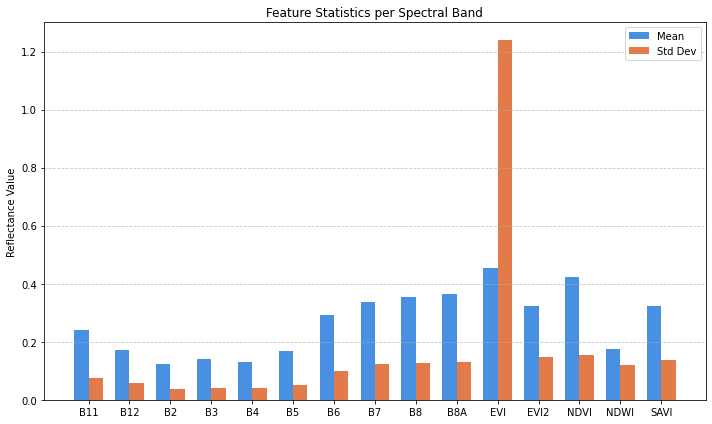

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Configuration: Ensure this matches the BANDS list in your project
# BANDS = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']

def plot_feature_stats(bands, means, stds):
    x = np.arange(len(bands))  # the label locations
    width = 0.35  # the width of the bars

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Create grouped bars
    rects1 = ax.bar(x - width/2, means, width, label='Mean', color='#4a90e2')
    rects2 = ax.bar(x + width/2, stds, width, label='Std Dev', color='#e27a4a')

    # Add text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Reflectance Value')
    ax.set_title('Feature Statistics per Spectral Band')
    ax.set_xticks(x)
    ax.set_xticklabels(bands)
    ax.legend()

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    # Save the chart to a file you can download
    plt.savefig("feature_statistics.png", dpi=300)
    print("✅ Chart saved successfully as 'feature_statistics.png'")
    plt.show()

# Execute the plotting function
plot_feature_stats(BANDS, means, stds)